## Analyze Results

Data/SLE_Scanning_Radius.json: 377 successful, 0 failed
Data/SLE_Scanning_Amplitude.json: 324 successful, 0 failed
  radius=0.003835492068901658: removed 3/16 outliers from final_log_likelihood
  radius=2.3755717277526855: removed 1/16 outliers from test_rmse
  radius=4.747308254241943: removed 2/15 outliers from test_picp
  radius=4.747308254241943: removed 1/15 outliers from final_log_likelihood
  radius=9.4907808303833: removed 2/15 outliers from test_rmse
  radius=9.4907808303833: removed 2/15 outliers from test_crps mean
  radius=11.862517356872559: removed 2/15 outliers from test_rmse
  radius=11.862517356872559: removed 2/15 outliers from test_crps mean
  radius=14.2342529296875: removed 2/15 outliers from test_rmse
  radius=14.2342529296875: removed 2/15 outliers from test_crps mean
  radius=14.2342529296875: removed 1/15 outliers from final_log_likelihood
  radius=16.605989456176758: removed 1/15 outliers from test_rmse
  radius=16.605989456176758: removed 2/15 outliers from t

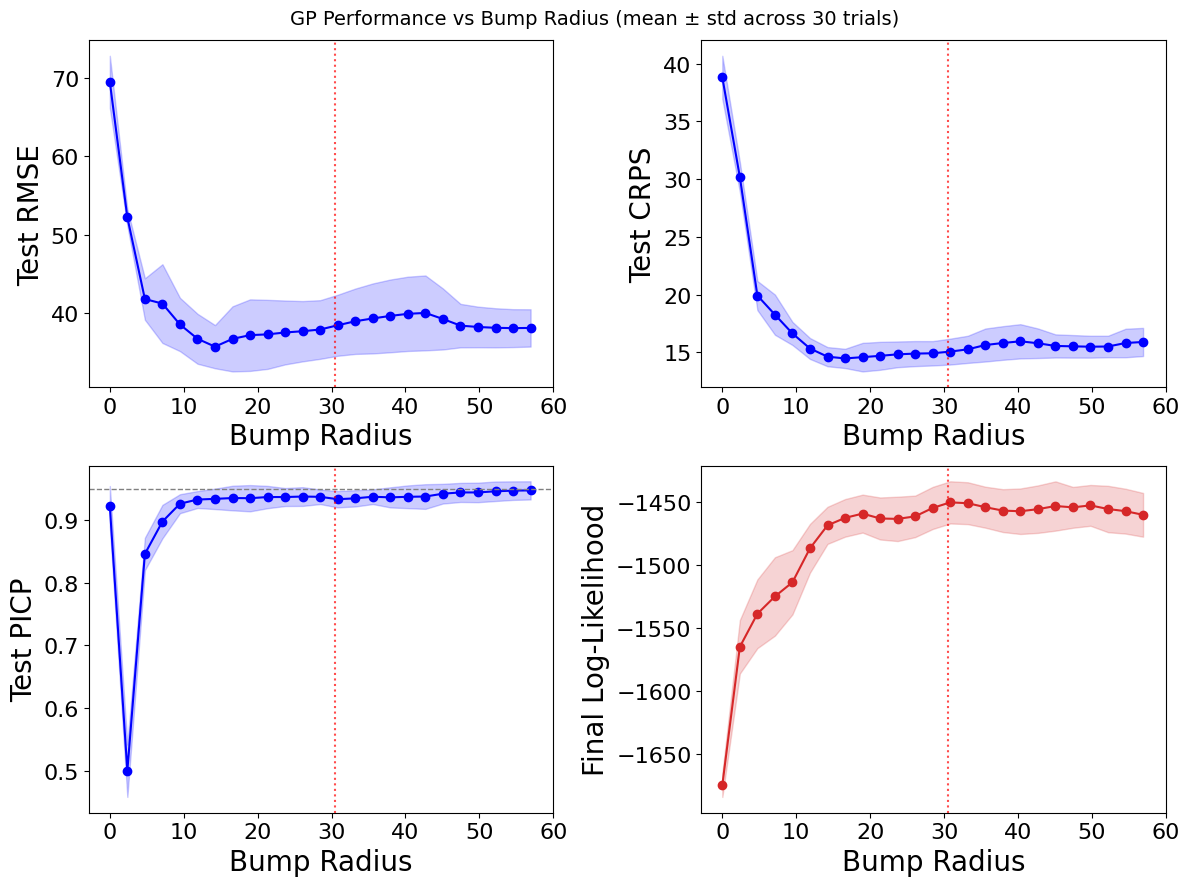

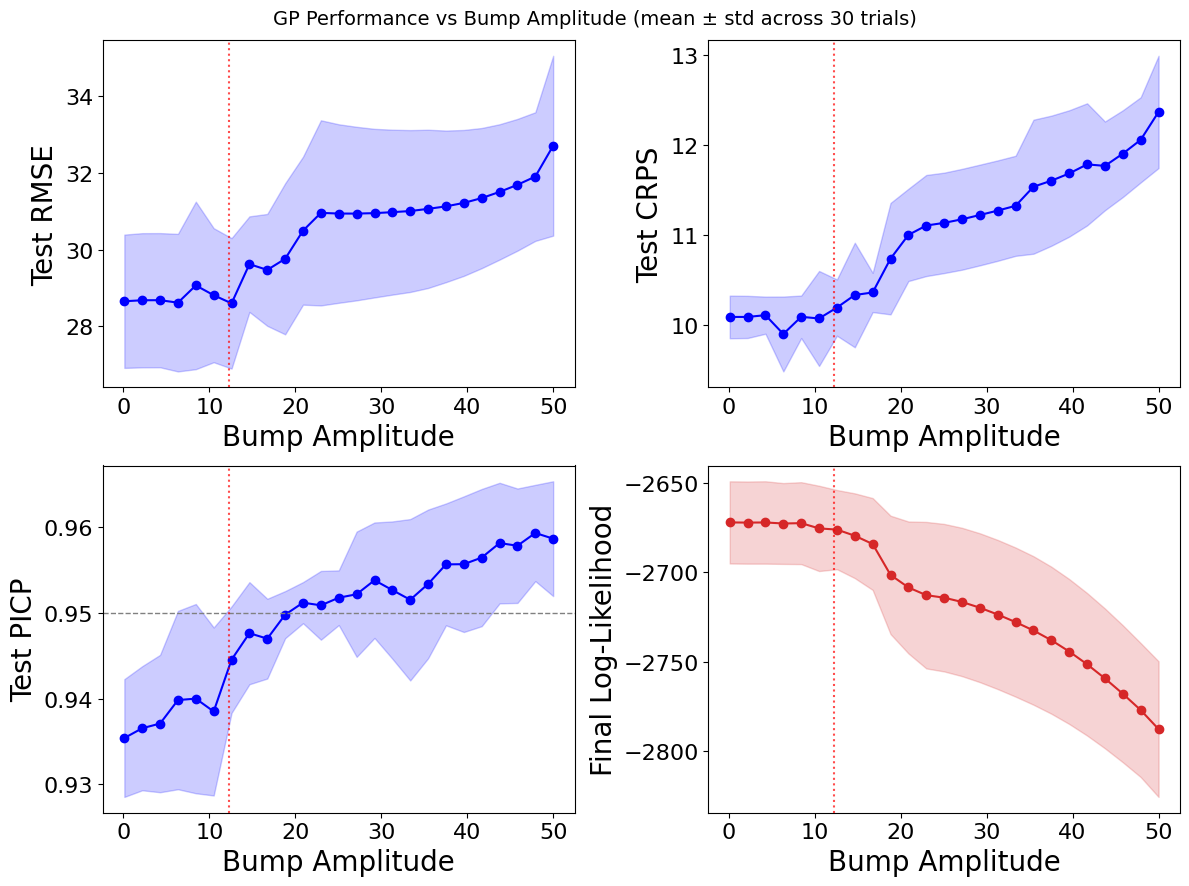

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

def load_results(filename):
    """Load results and separate successful runs from failed ones."""
    with open(filename, 'r') as f:
        results = json.load(f)

    successful = [r for r in results if 'error' not in r]
    failed = [r for r in results if 'error' in r]

    print(f"{filename}: {len(successful)} successful, {len(failed)} failed")
    return successful


def remove_outliers(values, method='iqr', k=1.5):
    """
    Return a boolean mask marking which entries in `values` are NOT outliers.

    method='iqr': flags values outside [Q1 - k*IQR, Q3 + k*IQR]
    method='mad': flags values outside k * MAD (median absolute deviation) from the median
    """
    values = np.asarray(values, dtype=float)

    finite_mask = np.isfinite(values)
    if finite_mask.sum() < 4:
        return finite_mask  # too few valid points to call anything an outlier

    if method == 'iqr':
        q1, q3 = np.percentile(values[finite_mask], [25, 75])
        iqr = q3 - q1
        lower, upper = q1 - k * iqr, q3 + k * iqr
        mask = (values >= lower) & (values <= upper)

    elif method == 'mad':
        med = np.median(values[finite_mask])
        mad = np.median(np.abs(values[finite_mask] - med)) * 1.4826
        if mad == 0:
            mask = np.ones(len(values), dtype=bool)
        else:
            z = np.abs(values - med) / mad
            mask = z <= k

    else:
        raise ValueError(f"Unknown method: {method}")

    return mask & finite_mask


def aggregate_by_param(results, param_name, remove_outliers_flag=True,
                        outlier_method='iqr', outlier_k=1.5, verbose=True):
    """
    Group results by the scanned parameter (radius or amplitude) and
    compute mean/std across trials for each metric.

    If remove_outliers_flag is True, outliers are removed independently
    per metric within each param group before computing mean/std.
    If False, all trials are used as-is (original behavior).
    """
    param_values = sorted(set(r[param_name] for r in results))

    metric_keys = {
        'test_rmse_mean': 'test_rmse',
        'test_crps_mean': 'test_crps mean',
        'test_picp_mean': 'test_picp',
        'log_likelihood_mean': 'final_log_likelihood',
    }

    agg = {
        param_name: [],
        'n_trials': [],
        'n_outliers_removed': {k: [] for k in metric_keys},
    }
    for mean_key in metric_keys:
        agg[mean_key] = []
        agg[mean_key.replace('_mean', '_std')] = []

    for val in param_values:
        matching = [r for r in results if np.isclose(r[param_name], val)]

        agg[param_name].append(val)
        agg['n_trials'].append(len(matching))

        for mean_key, raw_key in metric_keys.items():
            std_key = mean_key.replace('_mean', '_std')
            raw_vals = np.array([r[raw_key] for r in matching], dtype=float)

            if remove_outliers_flag:
                mask = remove_outliers(raw_vals, method=outlier_method, k=outlier_k)
                clean_vals = raw_vals[mask]
                n_removed = len(raw_vals) - len(clean_vals)
            else:
                clean_vals = raw_vals[np.isfinite(raw_vals)]  # still drop nan/inf to avoid corrupting mean
                n_removed = len(raw_vals) - len(clean_vals)

            agg['n_outliers_removed'][mean_key].append(n_removed)

            if len(clean_vals) == 0:
                clean_vals = raw_vals  # fallback if everything got filtered out

            agg[mean_key].append(np.mean(clean_vals))
            agg[std_key].append(np.std(clean_vals))

            if verbose and remove_outliers_flag and n_removed > 0:
                print(f"  {param_name}={val}: removed {n_removed}/{len(raw_vals)} outliers from {raw_key}")

    return agg

def plot_scan_results(agg, param_name, param_label, title, selected_value=None):
    """Create a 2x2 grid of plots: RMSE, CRPS, PICP, log-likelihood vs the scanned param.

    If selected_value is provided, a vertical dashed line marks the
    marginal-likelihood-optimized value of the swept parameter from the
    main experiment, for visual reference against the sweep.
    """

    Font_Size = 20
    Tick_Size = 16

    x = np.array(agg[param_name])
    custom_ticks = np.arange(0, 61, 10) if param_name == "radius" else None

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle(title, fontsize=14)

    def style_axis(ax):
        ax.set_xlabel(param_label, fontsize=Font_Size)
        ax.tick_params(axis='both', labelsize=Tick_Size)
        if custom_ticks is not None:
            ax.set_xticks(custom_ticks)
        if selected_value is not None:
            ax.axvline(selected_value, color='red', linestyle=':', alpha=0.7)# ,
                       #label=f'Likelihood-selected {param_label} = {selected_value:.2f}')

    # Test RMSE
    ax = axes[0, 0]
    mean = np.array(agg['test_rmse_mean'])
    std = np.array(agg['test_rmse_std'])
    ax.plot(x, mean, 'o-', color='blue')
    ax.fill_between(x, mean - std, mean + std, alpha=0.2, color='blue')
    ax.set_ylabel('Test RMSE', fontsize=Font_Size)
    style_axis(ax)

    # Test CRPS
    ax = axes[0, 1]
    mean = np.array(agg['test_crps_mean'])
    std = np.array(agg['test_crps_std'])
    ax.plot(x, mean, 'o-', color='blue')
    ax.fill_between(x, mean - std, mean + std, alpha=0.2, color='blue')
    ax.set_ylabel('Test CRPS', fontsize=Font_Size)
    style_axis(ax)

    # Test PICP
    ax = axes[1, 0]
    mean = np.array(agg['test_picp_mean'])
    std = np.array(agg['test_picp_std'])
    ax.plot(x, mean, 'o-', color='blue')
    ax.fill_between(x, mean - std, mean + std, alpha=0.2, color='blue')
    ax.axhline(0.95, color='gray', linestyle='--', linewidth=1) #, label='Target (0.95)')
    ax.set_ylabel('Test PICP', fontsize=Font_Size)
    style_axis(ax)
    # ax.legend(fontsize=Tick_Size)  # after style_axis so axvline label is included


    # Log-likelihood
    ax = axes[1, 1]
    mean = np.array(agg['log_likelihood_mean'])
    std = np.array(agg['log_likelihood_std'])
    ax.plot(x, mean, 'o-', color='C3')
    ax.fill_between(x, mean - std, mean + std, alpha=0.2, color='C3')
    ax.set_xlabel(param_label, fontsize=Font_Size)
    ax.set_ylabel('Final Log-Likelihood', fontsize=Font_Size)
    # ax.set_title('Final Log-Likelihood')
    # ax.grid(alpha=0.3)
    style_axis(ax)
    plt.tight_layout()
    return fig


REMOVE_OUTLIERS = True  # <-- set to False to disable outlier filtering

# ── Load both result files ─────────────────────────────────────────────
radius_filename = 'Data/SLE_Scanning_Radius.json'
amplitude_filename = 'Data/SLE_Scanning_Amplitude.json'

radius_results = load_results(radius_filename)
amplitude_results = load_results(amplitude_filename)

# ── Aggregate across trials ────────────────────────────────────────────
radius_agg = aggregate_by_param(radius_results, 'radius')
amplitude_agg = aggregate_by_param(amplitude_results, 'amplitude')

YOUR_R_VALUE_HERE = 3.05100554e+01 
YOUR_A_VALUE_HERE = 1.22510916e+01

# ── Plot ────────────────────────────────────────────────────────────────
fig_radius = plot_scan_results(
    radius_agg, 'radius', 'Bump Radius',
    'GP Performance vs Bump Radius (mean ± std across 30 trials)',
    selected_value=YOUR_R_VALUE_HERE
)
# fig_radius.savefig('/Users/MAlghalayini/Desktop/Postdoc Work/CAMERA gpLVM/Manuscript/Figures/Teddy Bear Results/radius_scan_results.pdf', dpi=150, bbox_inches='tight')



fig_amplitude = plot_scan_results(
    amplitude_agg, 'amplitude', 'Bump Amplitude',
    'GP Performance vs Bump Amplitude (mean ± std across 30 trials)',
    selected_value=YOUR_A_VALUE_HERE
)
# fig_amplitude.savefig('/Users/MAlghalayini/Desktop/Postdoc Work/CAMERA gpLVM/Manuscript/Figures/Teddy Bear Results/amplitude_scan_results.pdf', dpi=150, bbox_inches='tight')

plt.show()

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

def load_results(filename):
    with open(filename, 'r') as f:
        results = json.load(f)
    successful = [r for r in results if 'error' not in r]
    failed = [r for r in results if 'error' in r]
    print(f"{filename}: {len(successful)} successful, {len(failed)} failed")
    return successful

# ── Step 1: inspect keys to find the correct field name for signal variance ──
amplitude_filename = 'Data/SLE_Scanning_Amplitude.json'
amplitude_results = load_results(amplitude_filename)

print("Available keys in a sample result:")
print(list(amplitude_results[0].keys()))

Data/SLE_Scanning_Amplitude.json: 324 successful, 0 failed
Available keys in a sample result:
['training_size', 'amplitude', 'trial', 'seed', 'train_rmse', 'test_rmse', 'test_crps mean', 'test_crps std', 'test_picp', 'final_log_likelihood', 'final_hyperparameters', 'n_training_points']


teddy_example_gp_experiment_results_Matern_Scanning_Amplitude.json: 324 successful, 0 failed


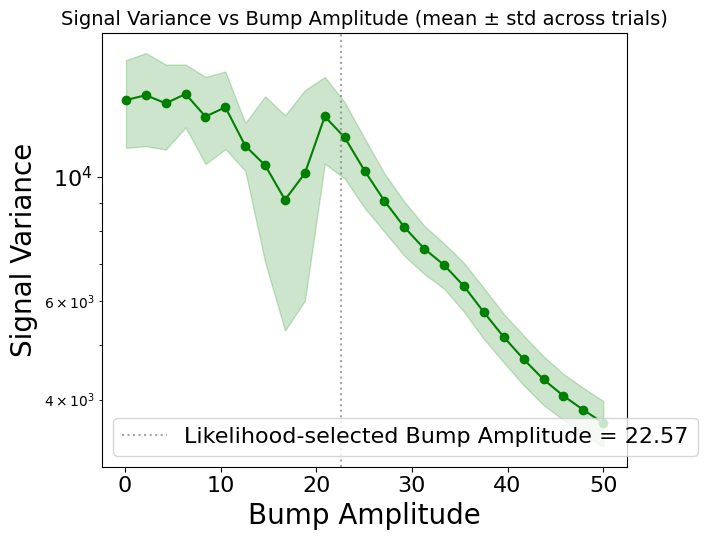

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

def load_results(filename):
    with open(filename, 'r') as f:
        results = json.load(f)
    successful = [r for r in results if 'error' not in r]
    failed = [r for r in results if 'error' in r]
    print(f"{filename}: {len(successful)} successful, {len(failed)} failed")
    return successful


def remove_outliers(values, method='iqr', k=1.5):
    values = np.asarray(values, dtype=float)
    finite_mask = np.isfinite(values)
    if finite_mask.sum() < 4:
        return finite_mask
    if method == 'iqr':
        q1, q3 = np.percentile(values[finite_mask], [25, 75])
        iqr = q3 - q1
        lower, upper = q1 - k * iqr, q3 + k * iqr
        mask = (values >= lower) & (values <= upper)
    elif method == 'mad':
        med = np.median(values[finite_mask])
        mad = np.median(np.abs(values[finite_mask] - med)) * 1.4826
        mask = np.ones(len(values), dtype=bool) if mad == 0 else (np.abs(values - med) / mad <= k)
    else:
        raise ValueError(f"Unknown method: {method}")
    return mask & finite_mask


def aggregate_hyperparam(results, param_name, hp_index, hp_label,
                          remove_outliers_flag=True, outlier_method='iqr', outlier_k=1.5):
    """
    Aggregate one entry of `final_hyperparameters` (indexed by hp_index)
    by the scanned parameter (param_name).
    """
    param_values = sorted(set(r[param_name] for r in results))
    agg = {param_name: [], f'{hp_label}_mean': [], f'{hp_label}_std': [], 'n_trials': []}

    for val in param_values:
        matching = [r for r in results if np.isclose(r[param_name], val)]
        agg[param_name].append(val)
        agg['n_trials'].append(len(matching))

        raw_vals = np.array([r['final_hyperparameters'][hp_index] for r in matching], dtype=float)

        if remove_outliers_flag:
            mask = remove_outliers(raw_vals, method=outlier_method, k=outlier_k)
            clean_vals = raw_vals[mask]
        else:
            clean_vals = raw_vals[np.isfinite(raw_vals)]

        if len(clean_vals) == 0:
            clean_vals = raw_vals

        agg[f'{hp_label}_mean'].append(np.mean(clean_vals))
        agg[f'{hp_label}_std'].append(np.std(clean_vals))

    return agg


def plot_hyperparam(agg, param_name, param_label, hp_label, hp_display_name,
                     title, selected_value=None, log_y=False):
    Font_Size = 20
    Tick_Size = 16

    x = np.array(agg[param_name])
    mean = np.array(agg[f'{hp_label}_mean'])
    std = np.array(agg[f'{hp_label}_std'])

    fig, ax = plt.subplots(figsize=(7, 5.5))
    ax.plot(x, mean, 'o-', color='green')
    ax.fill_between(x, mean - std, mean + std, alpha=0.2, color='green')
    ax.set_xlabel(param_label, fontsize=Font_Size)
    ax.set_ylabel(hp_display_name, fontsize=Font_Size)
    ax.tick_params(axis='both', labelsize=Tick_Size)
    ax.set_title(title, fontsize=14)

    if log_y:
        ax.set_yscale('log')

    if param_name == "radius":
        ax.set_xticks(np.arange(0, 60, 5))

    if selected_value is not None:
        ax.axvline(selected_value, color='gray', linestyle=':', alpha=0.7,
                   label=f'Likelihood-selected {param_label} = {selected_value:.2f}')
        ax.legend(fontsize=Tick_Size)

    plt.tight_layout()
    return fig


# ── Load amplitude sweep results ─────────────────────────────────────────
amplitude_filename = 'Data/SLE_Scanning_Amplitude.json'
amplitude_results = load_results(amplitude_filename)

# ── Aggregate signal variance (index 0) by amplitude ─────────────────────
sv_agg = aggregate_hyperparam(amplitude_results, 'amplitude', hp_index=0, hp_label='signal_variance')

fig_sv = plot_hyperparam(
    sv_agg, 'amplitude', 'Bump Amplitude', 'signal_variance', 'Signal Variance',
    'Signal Variance vs Bump Amplitude (mean ± std across trials)',
    selected_value=22.57,  # or whichever value you settle on
    log_y=True             # given the scale (~500,000 init -> ~6,000-7,000 optimized)
)
plt.show()

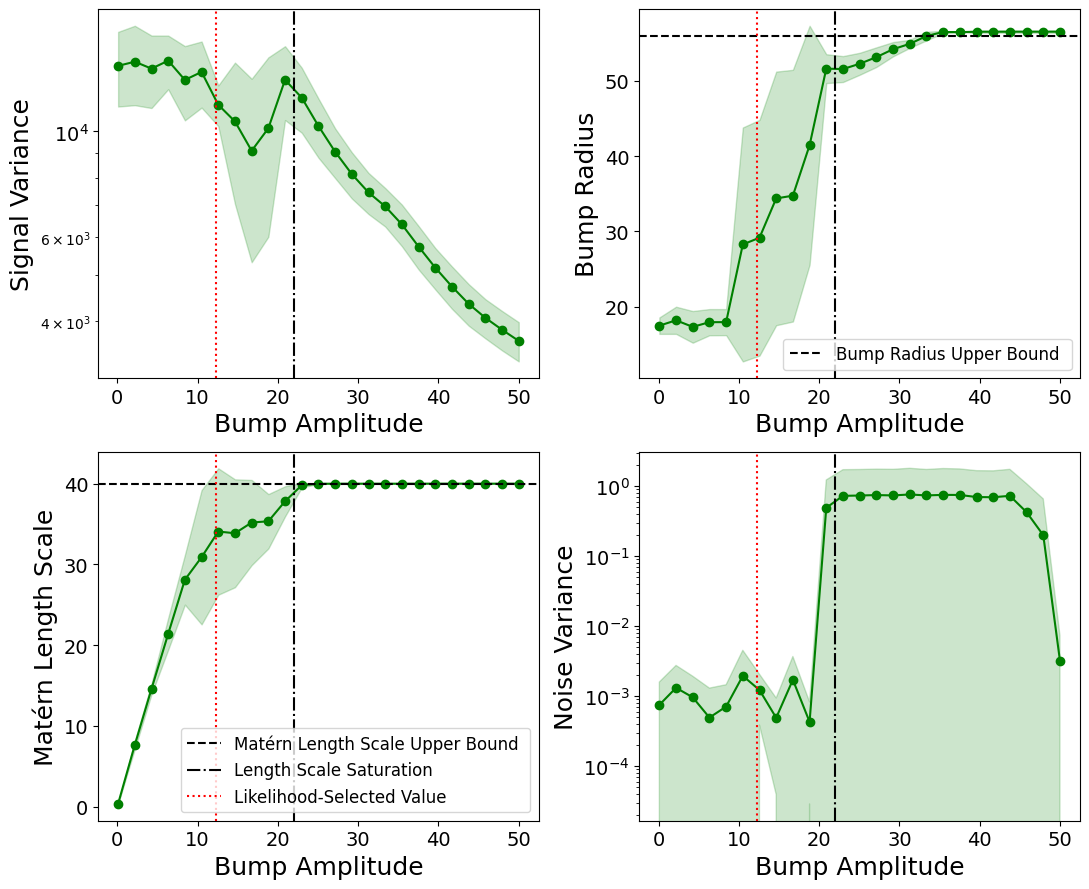

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── Confirmed hyperparameter index order in `final_hyperparameters` ──────
HP_INDICES = {
    'signal_variance': 0,
    'radius':          1,
    'length_scale':    2,
    'noise_variance':  3,
}

# ── Known/configured bounds and reference points for this sweep ──────────
LENGTH_SCALE_MAX = 40.0
RADIUS_MAX = 56
LENGTH_SCALE_SATURATION = 22.0   # amplitude at which length scale hits its bound
LIKELIHOOD_SELECTED_AMPLITUDE = 1.22510916e+01

# Panel in which the vertical reference lines (saturation, likelihood-selected
# amplitude) get their legend entries; drawn on every panel, but labeled once.
VLINE_LEGEND_PANEL = 'length_scale'

# ── Step 1: aggregate all four hyperparameters vs. amplitude ─────────────
aggs = {}
for hp_label, idx in HP_INDICES.items():
    aggs[hp_label] = aggregate_hyperparam(
        amplitude_results, 'amplitude', hp_index=idx, hp_label=hp_label
    )

# ── Step 2: plot all four in a 2x2 grid, with bound/saturation reference lines ──
def plot_all_hyperparams(aggs, param_name='amplitude', param_label='Bump Amplitude',
                          selected_value=None, saturation_onset=None,
                          hp_bounds=None, log_flags=None,
                          vline_legend_panel=None, save_path=None):
    log_flags = log_flags or {}
    hp_bounds = hp_bounds or {}
    labels_display = {
        'signal_variance': 'Signal Variance',
        'radius': 'Bump Radius',
        'length_scale': 'Matérn Length Scale',
        'noise_variance': 'Noise Variance',
    }
    Font_Size = 18
    Tick_Size = 14

    hp_order = ['signal_variance', 'radius', 'length_scale', 'noise_variance']
    hp_order = [hp for hp in hp_order if hp in aggs]

    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    axes = axes.flatten()

    for ax, hp_label in zip(axes, hp_order):
        agg = aggs[hp_label]
        x = np.array(agg[param_name])
        mean = np.array(agg[f'{hp_label}_mean'])
        std = np.array(agg[f'{hp_label}_std'])
        y_name = labels_display.get(hp_label, hp_label)
        is_vline_legend_panel = (hp_label == vline_legend_panel)

        ax.plot(x, mean, 'o-', color='green')
        ax.fill_between(x, mean - std, mean + std, alpha=0.2, color='green')
        ax.set_xlabel(param_label, fontsize=Font_Size)
        ax.set_ylabel(y_name, fontsize=Font_Size)
        ax.tick_params(axis='both', labelsize=Tick_Size)

        if log_flags.get(hp_label, False):
            ax.set_yscale('log')

        # Horizontal reference line: this panel's own y-quantity upper bound.
        # Labeled in every panel that has one, since the value differs per panel.
        bound = hp_bounds.get(hp_label)
        if bound is not None:
            ax.axhline(bound, color='black', linestyle='--', alpha=1,
                       label=f'{y_name} Upper Bound ') #= {bound:.1f}')

        # Vertical reference line: amplitude at which length scale saturates.
        # Drawn on every panel for visual alignment, but only labeled (and
        # thus only appearing in the legend) on the designated panel.
        if saturation_onset is not None:
            label = (f'Length Scale Saturation' # (a ≈ {saturation_onset:.0f})'
                      if is_vline_legend_panel else None)
            ax.axvline(saturation_onset, color='black', linestyle='-.', alpha=1,
                       label=label)

        # Vertical reference line: likelihood-selected amplitude.
        # Same treatment: drawn everywhere, labeled only once.
        if selected_value is not None:
            label = (f'Likelihood-Selected Value'# = {selected_value:.2f}'
                      if is_vline_legend_panel else None)
            ax.axvline(selected_value, color='red', linestyle=':', alpha=1,
                       label=label)

        # Only draw a legend if this panel has at least one labeled handle
        handles, legend_labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(fontsize=12, loc='lower right')

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    return fig

fig = plot_all_hyperparams(
    aggs,
    selected_value=LIKELIHOOD_SELECTED_AMPLITUDE,
    saturation_onset=LENGTH_SCALE_SATURATION,
    hp_bounds={'length_scale': LENGTH_SCALE_MAX, 'radius': RADIUS_MAX},
    log_flags={'signal_variance': True, 'noise_variance': True},
    vline_legend_panel=VLINE_LEGEND_PANEL,
)
plt.show()

# Plotting the kernel Sweep

Data/SLE_Inner_Kernel_Comparison.json: 45 successful, 0 failed
  matern52: 15 trials
  matern32: 15 trials
  rbf: 15 trials


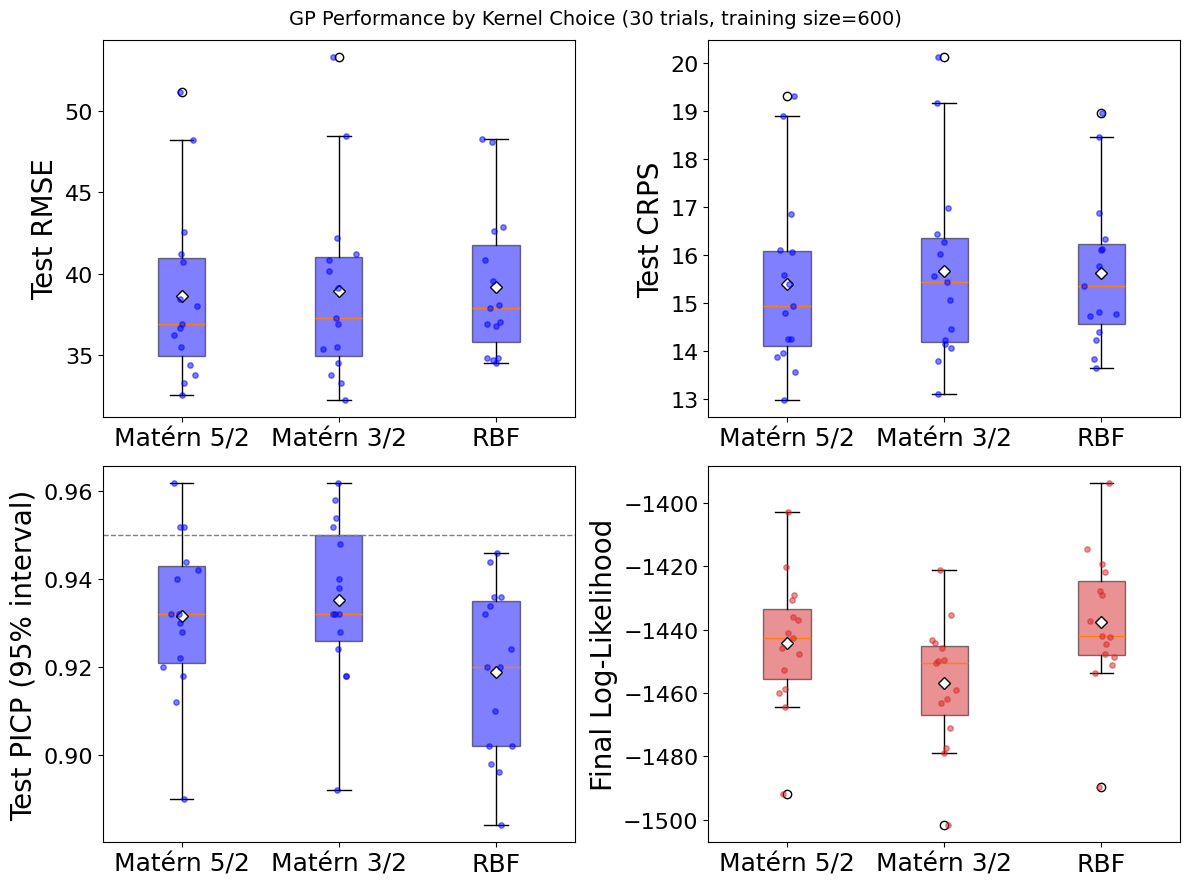

In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt

def load_results(filename):
    """Load results and separate successful runs from failed ones."""
    with open(filename, 'r') as f:
        results = json.load(f)
    
    successful = [r for r in results if 'error' not in r]
    failed = [r for r in results if 'error' in r]
    
    print(f"{filename}: {len(successful)} successful, {len(failed)} failed")
    return successful

def group_by_kernel(results, kernel_order=None):
    """
    Group metric values by kernel name.
    Returns a dict: {metric_name: {kernel_name: [values across trials]}}
    """
    if kernel_order is None:
        kernel_order = sorted(set(r['kernel'] for r in results))
    
    metrics = ['test_rmse', 'test_crps mean', 'test_picp', 'final_log_likelihood']
    
    grouped = {metric: {k: [] for k in kernel_order} for metric in metrics}
    
    for r in results:
        kernel = r['kernel']
        if kernel not in grouped['test_rmse']:
            continue
        for metric in metrics:
            grouped[metric][kernel].append(r[metric])
    
    # Print completion counts
    for kernel in kernel_order:
        n = len(grouped['test_rmse'][kernel])
        print(f"  {kernel}: {n} trials")
    
    return grouped, kernel_order

def plot_kernel_comparison(grouped, kernel_order, title='Kernel Comparison'):
    """Create a 2x2 grid of box plots comparing kernels across 4 metrics."""
    
    Font_Size = 20
    Tick_Size = 16
    Title_Size = 18
    XLabel_Size = 18

    metric_info = [
        ('test_rmse', 'Test RMSE', 'blue'),
        ('test_crps mean', 'Test CRPS', 'blue'),
        ('test_picp', 'Test PICP (95% interval)', 'blue'),
        ('final_log_likelihood', 'Final Log-Likelihood', 'C3'),
    ]
    
    # Nicer display labels for kernels
    label_map = {
        'matern52': 'Matérn 5/2',
        'matern32': 'Matérn 3/2',
        'rbf': 'RBF',
    }
    display_labels = [label_map.get(k, k) for k in kernel_order]
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle(title, fontsize=14)
    axes_flat = axes.flatten()
    
    for (metric_key, metric_label, color), ax in zip(metric_info, axes_flat):
        data = [grouped[metric_key][k] for k in kernel_order]
        
        bp = ax.boxplot(data, tick_labels=display_labels, patch_artist=True,
                        showmeans=True, meanprops={'marker': 'D', 'markerfacecolor': 'white',
                                                    'markeredgecolor': 'black', 'markersize': 6})
        
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_alpha(0.5)
        
        # Overlay individual points (jittered) for transparency into spread
        for i, d in enumerate(data):
            x_jitter = np.random.normal(i + 1, 0.04, size=len(d))
            ax.scatter(x_jitter, d, color=color, alpha=0.5, s=15, zorder=3)
        
        if metric_key == 'test_picp':
            ax.axhline(0.95, color='gray', linestyle='--', linewidth=1) #, label='Target (0.95)')
            # ax.legend(fontsize=14)
        
        ax.set_ylabel(metric_label, fontsize=Font_Size)
        # ax.set_title(metric_label, fontsize=Title_Size)

        # Increase x-tick label size (kernel names) and y-tick value size
        ax.tick_params(axis='x', labelsize=XLabel_Size)
        ax.tick_params(axis='y', labelsize=Tick_Size)
        # ax.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    return fig


# ── Load results ────────────────────────────────────────────────────────
results_filename = 'Data/SLE_Inner_Kernel_Comparison.json'
results = load_results(results_filename)

# ── Group by kernel ─────────────────────────────────────────────────────
kernel_order = ['matern52', 'matern32', 'rbf']  # fixed order for consistent plotting
grouped, kernel_order = group_by_kernel(results, kernel_order=kernel_order)

# ── Plot ────────────────────────────────────────────────────────────────
fig = plot_kernel_comparison(grouped, kernel_order,
                              title='GP Performance by Kernel Choice (30 trials, training size=600)')

plt.show()

In [8]:
171-156

15